## Mini-Projet Big Data — Sujet A : Avis clients e-commerce
Pipeline **Apache Spark → MongoDB** sur le dataset *Amazon Fine Food Reviews*.

Étapes : ingestion → nettoyage → 3 indicateurs → stockage NoSQL (MongoDB).

## 1. Initialisation de la SparkSession

In [32]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = SparkSession.builder \
    .appName("AvisEcommerce") \
    .config("spark.driver.memory", "2g") \
    .getOrCreate()

spark

## 2. Ingestion des données
Le fichier contient des guillemets mal échappés dans certains avis : `multiLine` et `escape` corrigent le parsing.

In [28]:
CHEMIN_CSV = "Reviews.csv"

df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .option("multiLine", True) \
    .option("escape", '"') \
    .csv(CHEMIN_CSV)

df.printSchema()

root
 |-- Id: integer (nullable = true)
 |-- ProductId: string (nullable = true)
 |-- UserId: string (nullable = true)
 |-- ProfileName: string (nullable = true)
 |-- HelpfulnessNumerator: integer (nullable = true)
 |-- HelpfulnessDenominator: integer (nullable = true)
 |-- Score: integer (nullable = true)
 |-- Time: integer (nullable = true)
 |-- Summary: string (nullable = true)
 |-- Text: string (nullable = true)



In [29]:
# Aperçu du volume brut et du partitionnement initial
print("Nombre de lignes brutes :", df.count())
print("Nombre de partitions :", df.rdd.getNumPartitions())

Nombre de lignes brutes : 568454
Nombre de partitions : 1


## 3. Nettoyage des données
Trois règles imposées par le sujet : valeurs manquantes, doublons, notes hors échelle (1-5).

`repartition(4)` corrige le partitionnement initial à 1 seule partition, pour mieux paralléliser le traitement sur les cœurs disponibles.

In [30]:
df_full_clean = df.dropna(subset=["ProductId", "Score", "Text"]) \
    .dropDuplicates() \
    .withColumn("Score", F.expr("try_cast(Score as float)")) \
    .filter((F.col("Score") >= 1) & (F.col("Score") <= 5)) \
    .repartition(4) \
    .cache()

print("Lignes après nettoyage complet :", df_full_clean.count())

Lignes après nettoyage complet : 568454


### Test de robustesse du nettoyage
Le dataset reel ne contient ni valeur manquante, ni doublon, ni note hors echelle. Pour prouver que le pipeline fonctionne réellement, on injecte 3 ligne volontairement corrompues et on vérifie qu'elles sont bien supprimees.

## 4. Indicateur 1 — Note moyenne par produit

In [7]:
stats_produits = df_full_clean.groupBy("ProductId").agg(
    F.round(F.avg("Score"), 2).alias("note_moyenne"),
    F.count("*").alias("nombre_avis")
).orderBy(F.desc("nombre_avis"))

stats_produits.show(10)

+----------+------------+-----------+
| ProductId|note_moyenne|nombre_avis|
+----------+------------+-----------+
|B007JFMH8M|        4.58|        913|
|B0026RQTGE|        4.59|        632|
|B002QWHJOU|        4.59|        632|
|B002QWP89S|        4.59|        632|
|B002QWP8H0|        4.59|        632|
|B003B3OOPA|        4.74|        623|
|B001EO5Q64|        4.75|        567|
|B006HYLW32|        4.31|        564|
|B0026KNQSA|        4.31|        564|
|B007M83302|        4.31|        564|
+----------+------------+-----------+
only showing top 10 rows


## 5. Indicateur 2 — Top produits
Seuil minimum de 10 avis pour tre eligible au classement, afin d'eviter qu'un produit avec tres peu d'avis ne fausse le resultat.

In [8]:
SEUIL_MIN_AVIS = 10

top_produits = stats_produits.filter(F.col("nombre_avis") >= SEUIL_MIN_AVIS) \
    .orderBy(F.desc("note_moyenne"), F.desc("nombre_avis")) \
    .limit(20)

top_produits.show(20)

+----------+------------+-----------+
| ProductId|note_moyenne|nombre_avis|
+----------+------------+-----------+
|B005EL6VOY|         5.0|         33|
|B000RL53PE|         5.0|         33|
|B001IZ9ME6|         5.0|         31|
|B0029O0XGQ|         5.0|         30|
|B00376ZEY6|         5.0|         30|
|B000LKZCQQ|         5.0|         26|
|B0016BS3BK|         5.0|         25|
|B000KXZ8E0|         5.0|         24|
|B000LEQ0QS|         5.0|         21|
|B001E5E2FE|         5.0|         20|
|B000F3YEPO|         5.0|         20|
|B0028VAQSU|         5.0|         20|
|B000YK7V9O|         5.0|         20|
|B000KEJMRI|         5.0|         19|
|B0001BH5YM|         5.0|         19|
|B000EDM6KU|         5.0|         19|
|B000YKD1JS|         5.0|         19|
|B001EQ4I5M|         5.0|         18|
|B0039CLK78|         5.0|         18|
|B000EMK4FA|         5.0|         18|
+----------+------------+-----------+



## 6. Indicateur 3 — Évolution mensuelle du volume d'avis
`Time` est un timestamp Unix ; conversion en `annee_mois` avant l'agregation.

In [9]:
df_full_clean = df_full_clean.withColumn(
    "annee_mois",
    F.date_format(F.from_unixtime(F.col("Time")), "yyyy-MM")
)

evolution_avis = df_full_clean.groupBy("annee_mois").agg(
    F.count("*").alias("nombre_avis")
).orderBy("annee_mois")

evolution_avis.show(30)

+----------+-----------+
|annee_mois|nombre_avis|
+----------+-----------+
|   1999-10|          2|
|   1999-12|          4|
|   2000-01|          8|
|   2000-02|          3|
|   2000-06|          5|
|   2000-07|          1|
|   2000-08|          5|
|   2000-10|          3|
|   2000-12|          7|
|   2001-02|          1|
|   2001-05|          1|
|   2001-06|          1|
|   2001-08|          3|
|   2001-09|          3|
|   2001-10|          3|
|   2001-12|          1|
|   2002-01|          3|
|   2002-02|         15|
|   2002-03|          6|
|   2002-04|          1|
|   2002-05|          2|
|   2002-06|          9|
|   2002-07|          4|
|   2002-08|          1|
|   2002-09|          1|
|   2002-10|          4|
|   2002-11|         21|
|   2002-12|          6|
|   2003-01|          4|
|   2003-02|          3|
+----------+-----------+
only showing top 30 rows


In [10]:
# Les mois les plus récents, pour observer le pic d'activité
evolution_avis.orderBy(F.desc("annee_mois")).show(10)

+----------+-----------+
|annee_mois|nombre_avis|
+----------+-----------+
|   2012-10|      20331|
|   2012-09|      21912|
|   2012-08|      19834|
|   2012-07|      19847|
|   2012-06|      18113|
|   2012-05|      19435|
|   2012-04|      18924|
|   2012-03|      19780|
|   2012-02|      18797|
|   2012-01|      21686|
+----------+-----------+
only showing top 10 rows


### Visualisation (bonus)

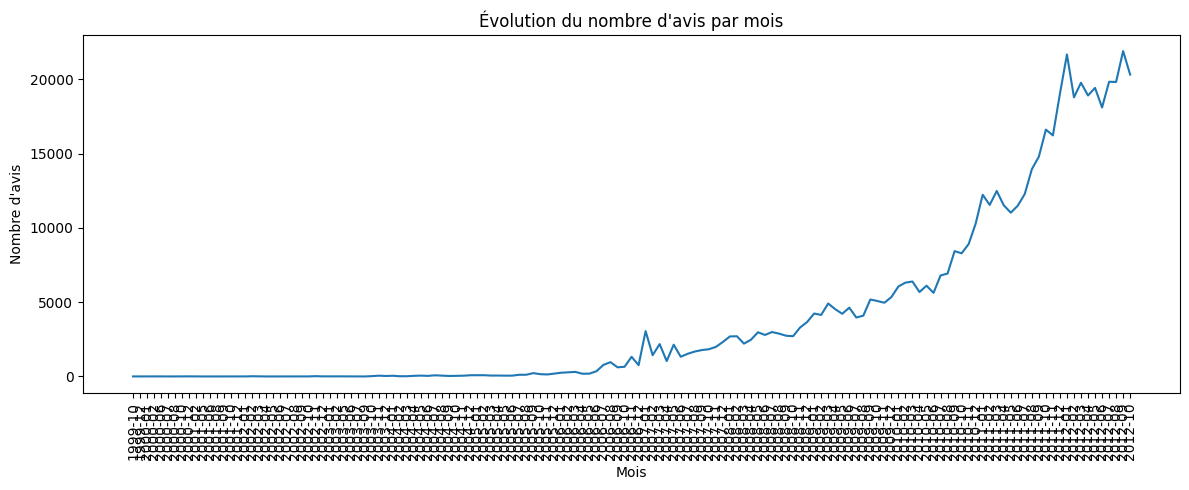

In [11]:
import matplotlib.pyplot as plt

pdf = evolution_avis.toPandas()

plt.figure(figsize=(12, 5))
plt.plot(pdf["annee_mois"], pdf["nombre_avis"])
plt.xticks(rotation=90)
plt.title("Évolution du nombre d'avis par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre d'avis")
plt.tight_layout()
plt.show()

## 7. Stockage des résultats dans MongoDB
Un document par produit, avec ses statistiques agregees imbriquees (modele NoSQL oriente documents).

In [12]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")
db = client["avis_ecommerce"]

print(client.list_database_names())

['admin', 'avis_ecommerce', 'config', 'local']


In [33]:
import pymongo

# 1. Convertir les agregations Spark en Pandas
df_pandas = stats_produits.toPandas()

# 2. Connexion conteneur Docker mongo_avis sur le port standard
try:
    client = pymongo.MongoClient("mongodb://localhost:27017/", serverSelectionTimeoutMS=5000)
    db = client["avis_ecommerce"]
    collection = db["stats_produits"]

    # 3. Mode 'overwrite' : vider puis insérer les nouvelles lignes
    collection.delete_many({})
    dictionnaires = df_pandas.to_dict(orient="records")
    
    if dictionnaires:
        collection.insert_many(dictionnaires)
        print(f"✅ Succès ! {len(dictionnaires)} produits enregistrés dans le conteneur 'mongo_avis'.")
    else:
        print("⚠️ Attention : Le DataFrame était vide, aucune donnée insérée.")

except Exception as e:
    print(f"❌ Erreur de connexion au conteneur Docker : {e}")
    print("👉 Vérifiez que le port 27017 de 'mongo_avis' est bien ouvert sur votre machine.")


✅ Succès ! 74258 produits enregistrés dans le conteneur 'mongo_avis'.


In [14]:
# Ensemble des ProductId présents dans le top 20, pour enrichir les documents
top_ids = set(row["ProductId"] for row in top_produits.select("ProductId").collect())
print("Nombre de top produits :", len(top_ids))

Nombre de top produits : 20


In [15]:
# Conversion en documents JSON
pdf_stats = stats_produits.toPandas()

documents = []
for _, row in pdf_stats.iterrows():
    documents.append({
        "_id": row["ProductId"],
        "note_moyenne": float(row["note_moyenne"]),
        "nombre_avis": int(row["nombre_avis"]),
        "est_top_produit": row["ProductId"] in top_ids
    })

print("Nombre de documents à insérer :", len(documents))
print(documents[0])

Nombre de documents à insérer : 74258
{'_id': 'B007JFMH8M', 'note_moyenne': 4.58, 'nombre_avis': 913, 'est_top_produit': False}


In [16]:
collection = db["stats_produits"]
collection.drop()
resultat = collection.insert_many(documents)

print(f"{len(resultat.inserted_ids)} documents insérés dans 'stats_produits'")

74258 documents insérés dans 'stats_produits'


In [17]:
print("Nombre de documents dans la collection :", collection.count_documents({}))
print(collection.find_one())

Nombre de documents dans la collection : 74258
{'_id': 'B007JFMH8M', 'note_moyenne': 4.58, 'nombre_avis': 913, 'est_top_produit': False}


In [18]:
pdf_evolution = evolution_avis.toPandas()

documents_evolution = []
for _, row in pdf_evolution.iterrows():
    documents_evolution.append({
        "annee_mois": row["annee_mois"],
        "nombre_avis": int(row["nombre_avis"])
    })

collection_evolution = db["evolution_avis"]
collection_evolution.drop()
resultat_evo = collection_evolution.insert_many(documents_evolution)

print(f"{len(resultat_evo.inserted_ids)} documents insérés dans 'evolution_avis'")

143 documents insérés dans 'evolution_avis'
